# Bagian 2 — Apple AppStore Analysis
## CRISP-DM Framework

## 1. Business Understanding

**Problem Statement:**
App developers and publishers want to understand what factors drive high user ratings
on the Apple AppStore. By predicting rating categories (Low/Medium/High), we can
help developers prioritize features and help Apple curate quality apps.

**Business Value:** Guides app development decisions, marketing strategies, and
AppStore curation to maximize user satisfaction.

## 2. Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/workspace/appleAppData.csv')
print('Shape:', df.shape)
df.head()

Shape: (1230376, 21)


,App_Id,App_Name,AppStore_Url,Primary_Genre,Content_Rating,Size_Bytes,Required_IOS_Version,Released,Updated,Version,...,Currency,Free,DeveloperId,Developer,Developer_Url,Developer_Website,Average_User_Rating,Reviews,Current_Version_Score,Current_Version_Reviews
0,com.hkbu.arc.apaper,A+ Paper Guide,https://apps.apple.com/us/app/a-paper-guide/id...,Education,4+,21993472.0,8.0,2017-09-28T03:02:41Z,2018-12-21T21:30:36Z,1.1.2,...,USD,True,1375410542,HKBU ARC,https://apps.apple.com/us/developer/hkbu-arc/i...,NaN,0.0,0,0.0,0
1,com.dmitriev.abooks,A-Books,https://apps.apple.com/us/app/a-books/id103157...,Book,4+,13135872.0,10.0,2015-08-31T19:31:32Z,2019-07-23T20:31:09Z,1.3,...,USD,True,1031572001,Roman Dmitriev,https://apps.apple.com/us/developer/roman-dmit...,NaN,5.0,1,5.0,1
2,no.terp.abooks,A-books,https://apps.apple.com/us/app/a-books/id145702...,Book,4+,21943296.0,9.0,2021-04-14T07:00:00Z,2021-05-30T21:08:54Z,1.3.1,...,USD,True,1457024163,Terp AS,https://apps.apple.com/us/developer/terp-as/id...,NaN,0.0,0,0.0,0
3,fr.antoinettefleur.Book1,A-F Book #1,https://apps.apple.com/us/app/a-f-book-1/id500...,Book,4+,81851392.0,8.0,2012-02-10T03:40:07Z,2019-10-29T12:40:37Z,1.2,...,USD,False,439568839,i-editeur.com,https://apps.apple.com/us/developer/i-editeur-...,NaN,0.0,0,0.0,0
4,com.imonstersoft.azdictionaryios,A-Z Synonyms Dictionary,https://apps.apple.com/us/app/a-z-synonyms-dic...,Reference,4+,64692224.0,9.0,2020-12-16T08:00:00Z,2020-12-18T21:36:11Z,1.0.1,...,USD,True,656731821,Ngov chiheang,https://apps.apple.com/us/developer/ngov-chihe...,http://imonstersoft.com,0.0,0,0.0,0


In [2]:
# Data types and missing values
print(df.info())
print('\nMissing values:')
print(df.isnull().sum().sort_values(ascending=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1230376 entries, 0 to 1230375
Data columns (total 21 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   App_Id                   1230376 non-null  object 
 1   App_Name                 1230375 non-null  object 
 2   AppStore_Url             1230376 non-null  object 
 3   Primary_Genre            1230376 non-null  object 
 4   Content_Rating           1230376 non-null  object 
 5   Size_Bytes               1230152 non-null  float64
 6   Required_IOS_Version     1230376 non-null  object 
 7   Released                 1230373 non-null  object 
 8   Updated                  1230376 non-null  object 
 9   Version                  1230376 non-null  object 
 10  Price                    1229886 non-null  float64
 11  Currency                 1230376 non-null  object 
 12  Free                     1230376 non-null  bool   
 13  DeveloperId              1230376 non-null 

In [3]:
# Basic stats
df[['Average_User_Rating', 'Reviews', 'Price', 'Size_Bytes']].describe()

,Average_User_Rating,Reviews,Price,Size_Bytes
count,1.230376e+06,1.230376e+06,1.229886e+06,1.230152e+06
mean,1.788387e+00,8.259478e+02,5.041264e-01,7.510857e+07
std,2.154105e+00,5.016051e+04,6.869674e+00,2.318726e+08
min,0.000000e+00,0.000000e+00,0.000000e+00,2.762800e+04
25%,0.000000e+00,0.000000e+00,0.000000e+00,2.041344e+07
50%,0.000000e+00,0.000000e+00,0.000000e+00,4.333158e+07
75%,4.333330e+00,3.000000e+00,0.000000e+00,8.365466e+07
max,5.000000e+00,2.268533e+07,9.999900e+02,7.677945e+10


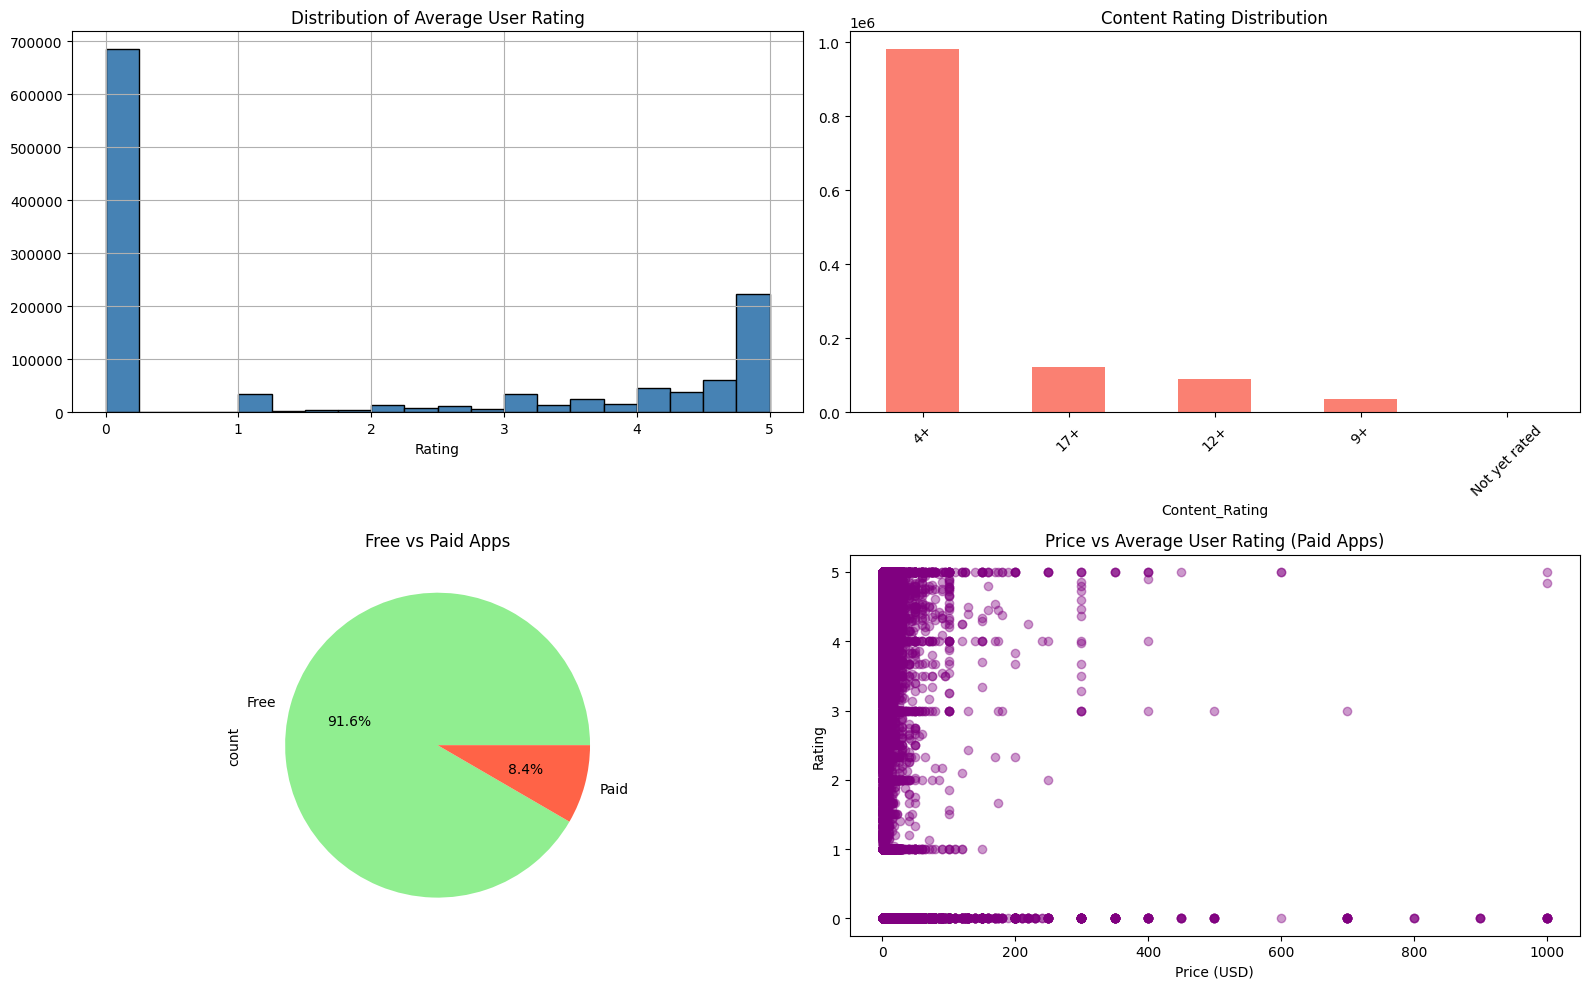

In [4]:
# --- Visualizations ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Rating Distribution
df['Average_User_Rating'].hist(bins=20, ax=axes[0,0], color='steelblue', edgecolor='black')
axes[0,0].set_title('Distribution of Average User Rating')
axes[0,0].set_xlabel('Rating')

# 2. Content Rating Distribution
df['Content_Rating'].value_counts().plot(kind='bar', ax=axes[0,1], color='salmon')
axes[0,1].set_title('Content Rating Distribution')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Free vs Paid
df['Free'].value_counts().plot(kind='pie', ax=axes[1,0], autopct='%1.1f%%',
                                colors=['lightgreen','tomato'], labels=['Free','Paid'])
axes[1,0].set_title('Free vs Paid Apps')

# 4. Price vs Rating (only paid apps)
paid = df[df['Price'] > 0]
axes[1,1].scatter(paid['Price'], paid['Average_User_Rating'], alpha=0.4, color='purple')
axes[1,1].set_title('Price vs Average User Rating (Paid Apps)')
axes[1,1].set_xlabel('Price (USD)')
axes[1,1].set_ylabel('Rating')

plt.tight_layout()
plt.savefig('apple_distributions.png', dpi=150)
plt.show()

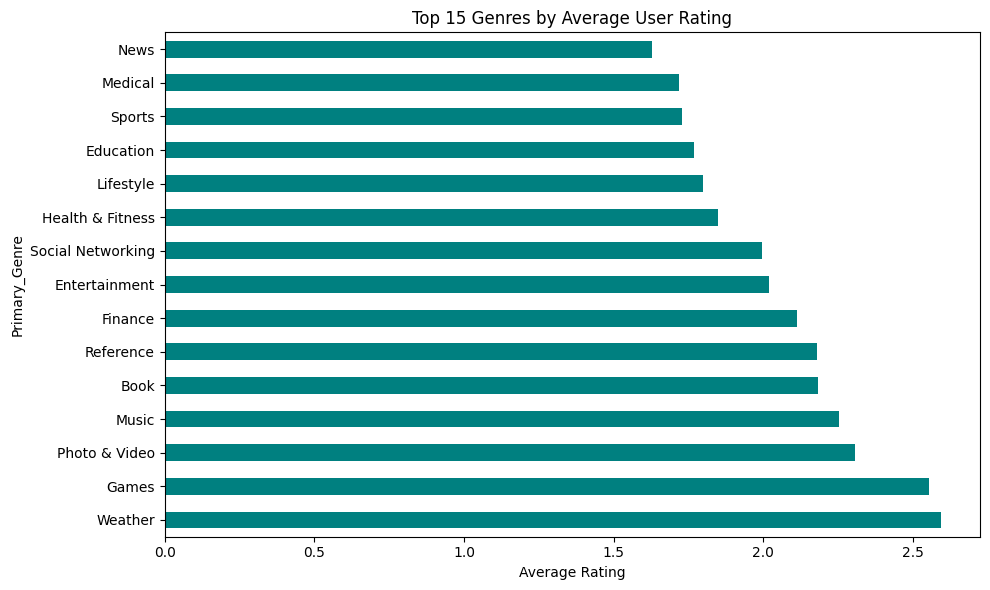

In [5]:
# Top genres by average rating
genre_rating = df.groupby('Primary_Genre')['Average_User_Rating'].mean().sort_values(ascending=False).head(15)
genre_rating.plot(kind='barh', figsize=(10, 6), color='teal')
plt.title('Top 15 Genres by Average User Rating')
plt.xlabel('Average Rating')
plt.tight_layout()
plt.savefig('genre_ratings.png', dpi=150)
plt.show()

## 3. Data Preprocessing & Feature Engineering

In [7]:
# --- Parse Dates ---
# Parse with UTC first, then drop timezone to keep all datetimes consistent (naive)
df['Released'] = pd.to_datetime(df['Released'], errors='coerce', utc=True).dt.tz_localize(None)
df['Updated']  = pd.to_datetime(df['Updated'],  errors='coerce', utc=True).dt.tz_localize(None)

# Match the same timezone style (naive)
reference_date = pd.Timestamp.now().tz_localize(None)

# --- Feature Engineering ---

# 1. App Age in days (since release)
df['App_Age_Days'] = (reference_date - df['Released']).dt.days

# 2. Days since last update
df['Days_Since_Update'] = (reference_date - df['Updated']).dt.days

# 3. Review Intensity (reviews per day since release)
df['Review_Intensity'] = df['Reviews'] / (df['App_Age_Days'] + 1)

# 4. Rating-to-Review Ratio
df['Rating_Review_Ratio'] = df['Average_User_Rating'] / (df['Reviews'] + 1)

# 5. Size in MB
df['Size_MB'] = df['Size_Bytes'] / 1_000_000

# 6. Is Free (convert boolean to int)
df['Is_Free'] = df['Free'].astype(int)

print(df[['App_Age_Days', 'Days_Since_Update', 'Review_Intensity',
          'Rating_Review_Ratio', 'Size_MB', 'Is_Free']].head())

   App_Age_Days  Days_Since_Update  Review_Intensity  Rating_Review_Ratio  \
0        3088.0               2639           0.00000                  0.0   
1        3847.0               2425           0.00026                  2.5   
2        1794.0               1748           0.00000                  0.0   
3        5145.0               2327           0.00000                  0.0   
4        1913.0               1911           0.00000                  0.0   

     Size_MB  Is_Free  
0  21.993472        1  
1  13.135872        1  
2  21.943296        1  
3  81.851392        0  
4  64.692224        1  


In [8]:
# --- Create Target Variable: Rating Category ---
# Apps with 0 rating are likely unrated — handle separately
df_model = df[df['Average_User_Rating'] > 0].copy()

def rating_category(r):
    if r < 3.5:
        return 'Low'
    elif r < 4.5:
        return 'Medium'
    else:
        return 'High'

df_model['Rating_Category'] = df_model['Average_User_Rating'].apply(rating_category)
print(df_model['Rating_Category'].value_counts())

Rating_Category
High      284262
Low       136864
Medium    124930
Name: count, dtype: int64


In [9]:
# --- Encode Categorical Features ---
from sklearn.preprocessing import LabelEncoder

le_genre   = LabelEncoder()
le_content = LabelEncoder()

df_model['Genre_Encoded']   = le_genre.fit_transform(df_model['Primary_Genre'].fillna('Unknown'))
df_model['Content_Encoded'] = le_content.fit_transform(df_model['Content_Rating'].fillna('Unknown'))

# Define feature set
FEATURES = [
    'Size_MB', 'Price', 'Is_Free', 'App_Age_Days', 'Days_Since_Update',
    'Review_Intensity', 'Rating_Review_Ratio', 'Reviews',
    'Genre_Encoded', 'Content_Encoded'
]

X = df_model[FEATURES].fillna(0)
y = df_model['Rating_Category']

print('Feature matrix shape:', X.shape)
print('Class distribution:\n', y.value_counts())

Feature matrix shape: (546056, 10)
Class distribution:
 Rating_Category
High      284262
Low       136864
Medium    124930
Name: count, dtype: int64


## 4. Data Modelling — Classification

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
import time

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}')

Train size: 436844, Test size: 109212


In [18]:
# --- Helper function to train + evaluate ---
def train_evaluate(model, X_tr, X_te, y_tr, y_te, model_name):
    start = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - start

    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_te, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_te, y_pred, average='weighted', zero_division=0)

    print(f'\n=== {model_name} ===')
    print(f'Training time : {train_time:.4f}s')
    print(f'Accuracy      : {acc:.4f}')
    print(f'Precision     : {prec:.4f}')
    print(f'Recall        : {rec:.4f}')
    print(f'F1 Score      : {f1:.4f}')
    print(classification_report(y_te, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_te, y_pred, labels=['Low', 'Medium', 'High'])
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Low', 'Medium', 'High'],
        yticklabels=['Low', 'Medium', 'High'],
    )
    plt.title(f'Confusion Matrix - {model_name}')
    plt.tight_layout()
    plt.savefig(f'cm_{model_name.replace(" ", "_")}.png', dpi=150)
    plt.show()

    return {
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'Training Time': train_time,
    }


=== Logistic Regression ===
Training time : 6.9699s
Accuracy      : 0.5873
Precision     : 0.5463
Recall        : 0.5873
F1 Score      : 0.5385
              precision    recall  f1-score   support

        High       0.65      0.83      0.73     56853
         Low       0.47      0.54      0.50     27373
      Medium       0.39      0.08      0.14     24986

    accuracy                           0.59    109212
   macro avg       0.50      0.49      0.46    109212
weighted avg       0.55      0.59      0.54    109212



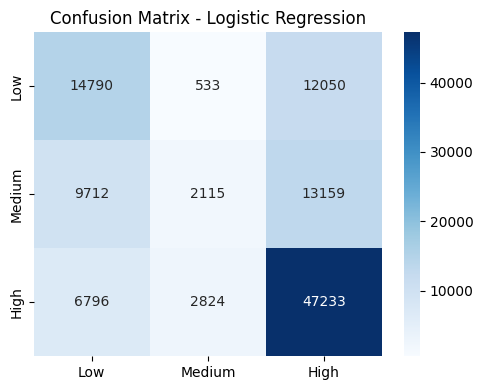

In [19]:
# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
metrics_lr = train_evaluate(
    lr, X_train_scaled, X_test_scaled, y_train, y_test, 'Logistic Regression'
)


=== Decision Tree ===
Training time : 1.3260s
Accuracy      : 0.7728
Precision     : 0.7699
Recall        : 0.7728
F1 Score      : 0.7659
              precision    recall  f1-score   support

        High       0.78      0.91      0.84     56853
         Low       0.86      0.72      0.79     27373
      Medium       0.64      0.52      0.57     24986

    accuracy                           0.77    109212
   macro avg       0.76      0.72      0.73    109212
weighted avg       0.77      0.77      0.77    109212



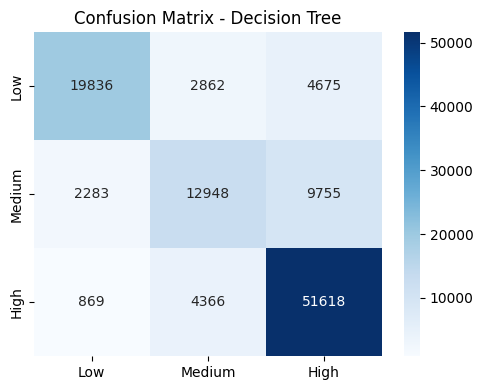

In [20]:
# 2. Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
metrics_dt = train_evaluate(
    dt, X_train, X_test, y_train, y_test, 'Decision Tree'
)


=== Random Forest ===
Training time : 61.2661s
Accuracy      : 0.9660
Precision     : 0.9660
Recall        : 0.9660
F1 Score      : 0.9659
              precision    recall  f1-score   support

        High       0.96      0.98      0.97     56853
         Low       1.00      0.98      0.99     27373
      Medium       0.94      0.91      0.93     24986

    accuracy                           0.97    109212
   macro avg       0.97      0.96      0.96    109212
weighted avg       0.97      0.97      0.97    109212



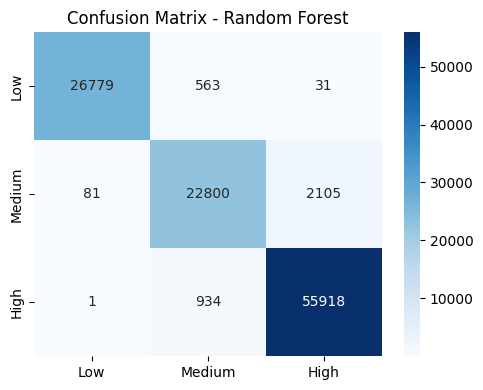

In [21]:
# 3. Random Forest (ensemble)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
metrics_rf = train_evaluate(
    rf, X_train, X_test, y_train, y_test, 'Random Forest'
)

## 5. Evaluation — Model Comparison

              Model  Accuracy  Precision   Recall       F1  Training Time
Logistic Regression  0.587280   0.546290 0.587280 0.538483       6.969894
      Decision Tree  0.772827   0.769938 0.772827 0.765908       1.326022
      Random Forest  0.965984   0.965985 0.965984 0.965866      61.266092


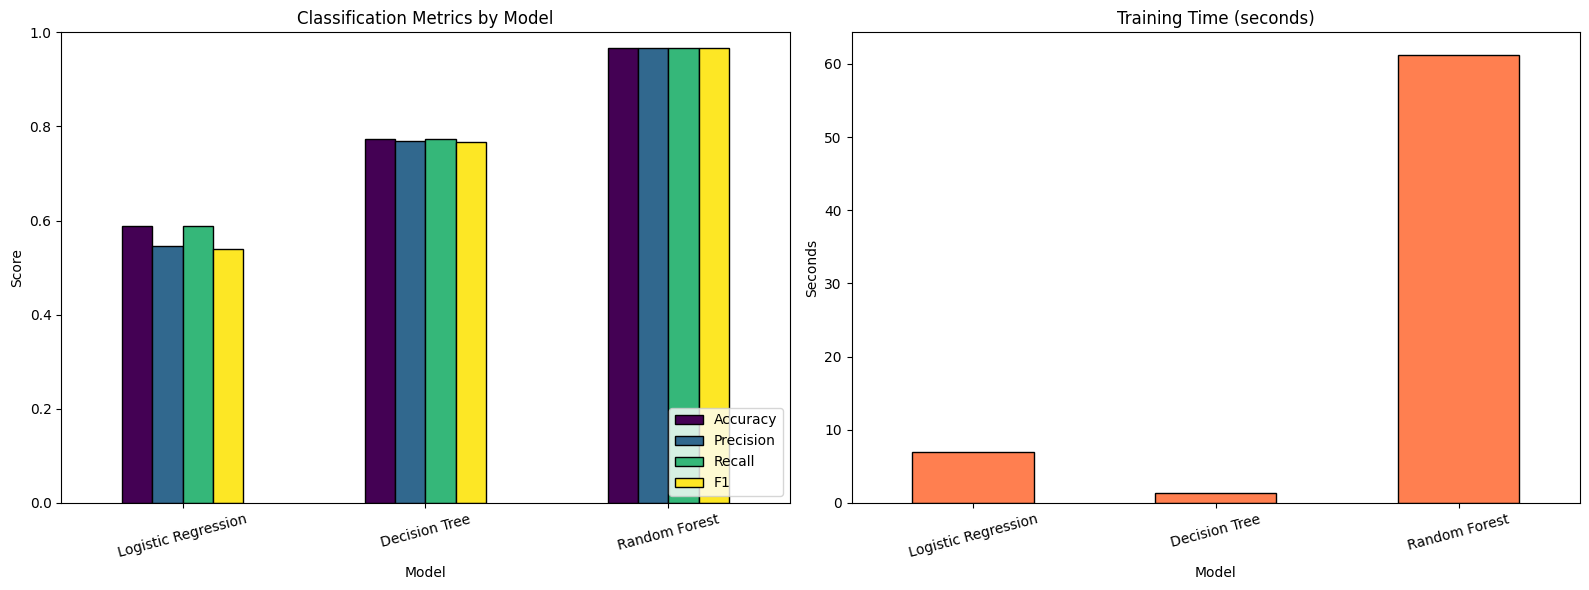

In [22]:
# Summary comparison table
results = pd.DataFrame([metrics_lr, metrics_dt, metrics_rf])
print(results[['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'Training Time']].to_string(index=False))

# Plot comparison with matplotlib
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1']
results.set_index('Model')[metric_cols].plot(
    kind='bar', ax=axes[0], colormap='viridis', edgecolor='black'
)
axes[0].set_title('Classification Metrics by Model')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(loc='lower right')

results.plot(
    x='Model', y='Training Time', kind='bar', ax=axes[1], legend=False, color='coral', edgecolor='black'
)
axes[1].set_title('Training Time (seconds)')
axes[1].set_ylabel('Seconds')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

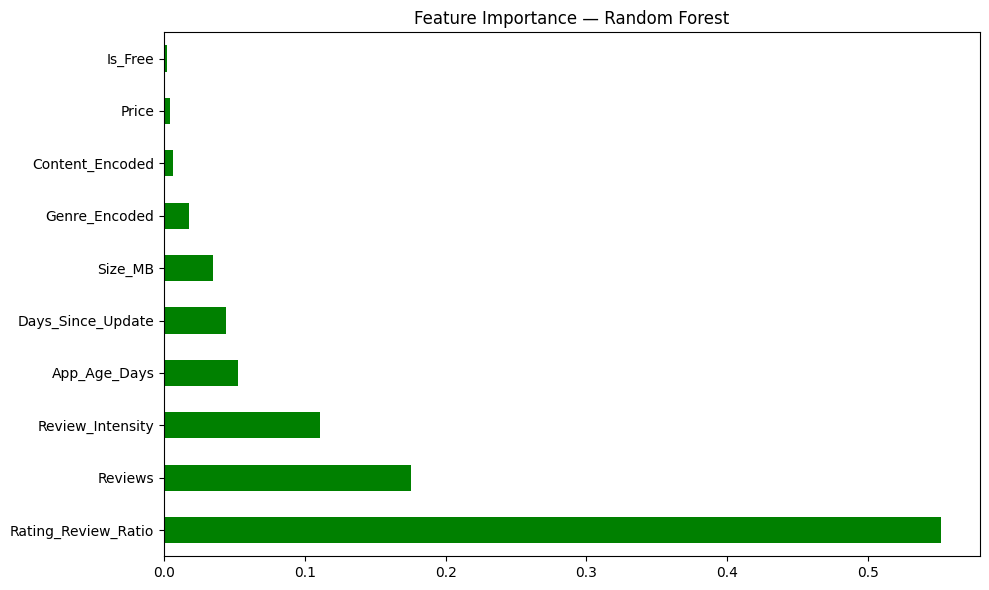

In [23]:
# Feature Importance (Random Forest)
feat_imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
feat_imp.plot(kind='barh', figsize=(10, 6), color='green')
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

## 6. Limitations & Lesson Learned

- **Limitations:** Ratings with 0 value were excluded (unrated apps); class imbalance may affect results (consider SMOTE or class_weight).
- **Challenges:** Many apps have 0 reviews making Review_Intensity meaningless; price distribution is heavily skewed (most apps are free).
- **Lesson Learned:** Feature engineering (App_Age, Review_Intensity) significantly improves model performance compared to using raw columns alone. Random Forest handles non-linear relationships better than Logistic Regression for this dataset.